<a href="https://colab.research.google.com/github/sambee5/data-science-coursework/blob/main/Unit3/SamaBhatU3proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Start by installing the required libraries.

In [2]:
!pip install "preliz[full,notebook]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.8/108.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.7/515.7 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.6/519.6 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 48.5 MB/s eta 0:00:00


In [3]:
import preliz as pz

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import arviz as az
import pymc as pm

# True Average of NCAA 100 Freestyle Championship Times

For this project, I'll be analyzing the 100 freestyle times at the D1 NCAA Championship Finals from years 2014-2024. In the United States, swimming regulations are typically in 25 yard distances, and the NCAA follows these guidelines as well. This is known as short course yards swimming. At the NCAA championships the best of the best D1 Schools like UT, Berkley, University of Tennesee, and University Of Florida all compete to accrue as much points as it takes to win. Many of these schools produce top tier American swimmers that make headlines in the Olympic scene. One of the most fastest and exciting events in swimming is the 100 freestyle.

Here's a bit of info that might be useful when interpreting this analysis:
*  Every time is in seconds
*  A 100 yard distance means a swimmer has to swim 4 laps in total (25 yd/lap)
*  Underwaters (swimming underwater; no stokes) are done at the start of each lap, and can only be done for the first 15 yards

In [5]:
#get data from github and plot it
raw_freestyle = 'https://raw.githubusercontent.com/sambee5/data-science-coursework/refs/heads/main/Unit3/Race_Summary_2.csv'
data_freestyle = pd.read_csv(raw_freestyle)

data_freestyle

,Average_Stroke_Rate,Tempo_Trend,Breakout_Time,Total_Race_Time,Source_File,Unique_ID,Race_Date,place,total_cycles,split_diff,Total_UW_Distance,Total_Swim_Distance,Yards/Cycle
0,1.14,0.11,4.12,41.59,H:/CaseStudy/casestudycsv\Daniel Krueger_100 F...,DanKruM100FreeF20210327,2021-03-27,2,24.5,2.03,NaN,NaN,NaN
1,1.12,0.07,5.36,40.89,H:/CaseStudy/casestudycsv\Ryan Hoffer_100 Free...,RyaHofM100FreeF20210327,2021-03-27,1,15.5,1.75,NaN,NaN,NaN
2,1.05,0.07,4.55,41.59,H:/CaseStudy/casestudycsv\Drew Kibler_100 Free...,DreKibM100FreeF20210327,2021-03-27,2,21.5,2.47,NaN,NaN,NaN
3,1.13,0.09,4.16,41.77,H:/CaseStudy/casestudycsv\Santo Condorelli_100...,SanConM100FreeF20170325,2017-03-25,5,23.0,2.57,35.0,65.0,2.826087
4,1.05,0.09,4.94,41.77,H:/CaseStudy/casestudycsv\Brett Ringgold_100 F...,BreRinM100FreeF20170325,2017-03-25,5,19.5,2.27,49.6,50.4,2.584615
...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,1.08,0.07,4.12,40.80,H:/CaseStudy/casestudycsv\Dean Farris_100 Free...,DeaFarM100FreeF20190330,2019-03-30,1,19.5,1.96,47.4,52.6,2.697436
63,1.15,0.06,4.89,42.00,H:/CaseStudy/casestudycsv\Justin Ress_100 Free...,JusResM100FreeF20190330,2019-03-30,7,23.0,1.90,36.3,63.7,2.769565
64,1.11,0.06,4.65,42.06,H:/CaseStudy/casestudycsv\Pawel Sendyk_100 Fre...,PawSenM100FreeF20190330,2019-03-30,8,20.0,2.36,47.6,52.4,2.620000
65,1.13,0.05,3.54,41.75,H:/CaseStudy/casestudycsv\Robert Howard_100 Fr...,RobHowM100FreeF20190330,2019-03-30,5,25.5,1.33,31.0,69.0,2.705882


There's a lot of super interesting info in this dataset! Just take a look at the Total UW Distance (distance a swimmer is underwater in yards). For some people, it's over HALF the entire race (100 yd). Isn't that absurd?! But for this project, I'll only be analyzing the swimming times for the 100 Freestyle in NCAA Swim & Dive Championship A finals.

In [6]:
#return times for every swimmer
race_times = data_freestyle['Total_Race_Time']
race_times

,Total_Race_Time
0,41.59
1,40.89
2,41.59
3,41.77
4,41.77
...,...
62,40.80
63,42.00
64,42.06
65,41.75


There are 67 swimmers in my dataset. The reason there is not an even number of swimmers (usually 8 swimmers per heat) is probably because a racer dropped out or got disqualified during the race. Covid-19 also cancelled the event in 2020.

(array([ 2.,  3.,  4., 11.,  6., 14., 15.,  3.,  5.,  4.]),
 array([39.9  , 40.183, 40.466, 40.749, 41.032, 41.315, 41.598, 41.881,
        42.164, 42.447, 42.73 ]),
 <BarContainer object of 10 artists>)

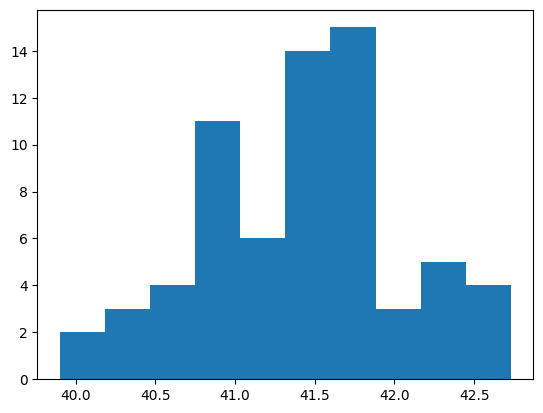

In [7]:
plt.hist(race_times)

On the histogram plotted above, we can see that there is a peak at around 41.75 seconds. This means that many swimmers competing in the A finals got this time between 2014 and 2024. We can see that the times get less frequent as the times get faster. This is because there is a limit to how fast a human can possibly go in the water. This means that there is a left skew to this graph. There can't realistically be a right skew since there is such a high barrier of entry when it comes to being a D1 swimmer who races this event.

The random spike at 40.75-ish seconds is likely noise. The reason there are so many times in this range is probably because swimmers are getting faster overall. These times are likely from recent years where competition has become more fierce than ever.

Since the times can only be positive real numbers, I think that the normal distribution is a great pick for our likelihood! I'll use the weibull distribution first though because it also appears to fit our data well. It sounds cool so I'll try that out first.

Now we've got to select our priors.

<Axes: >

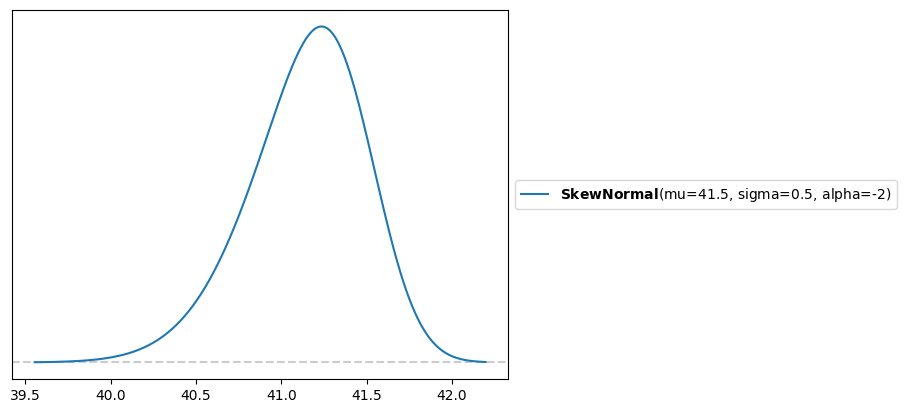

In [8]:
#the skewNormal distribution looks promising
pz.SkewNormal(mu=41.5, sigma=0.5, alpha=-2.0).plot_pdf()

I chose the SkewNormal distribution as my prior for the expected value because it looks roughly accurate with respects to what I've seen across all top level swimming (even after the time span in which this data was recorded). On the left end of the graph, it shows 39.5 and below as highly unlikely. This is true because it's never happened but there's been times close to it. Before Jordan Crooks' record 39.83 during the 2025 season, Caeleb Dressel swam a [39.90 back in 2018](https://www.youtube.com/watch?v=ipo3Ga56Cvk)

In [9]:
race_times.std()

0.6373474400865617

At this degree of competition, having each time differ from the mean time by around 0.64 seconds isn't too bad. This really tells us a lot about how cutthroat the swim meet is. Since we have a relatively small standard deviation, I think using the HalfNormal distribution is fine because it contains only positive numbers and has the most density around 0.

According to the preliz documentation, the variance (aka std dev^2) is present for the HalfNormal distribution in the form $σ^2(1-\frac{2}{π})$. When solving for $σ$ given all this info, we get a value of ~1.06. That's what I'll be using in the distribution.

<Axes: >

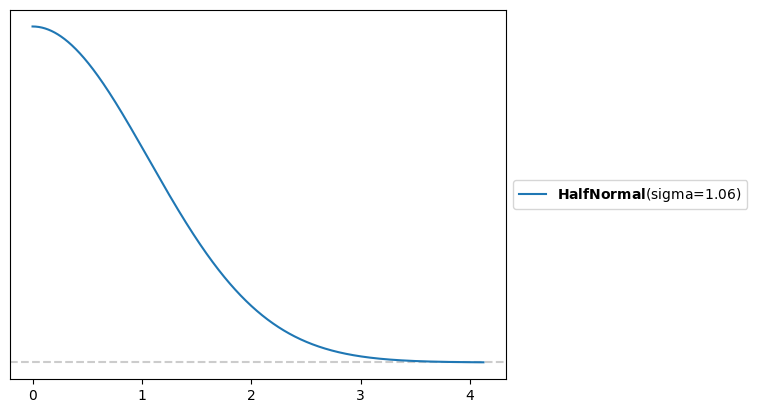

In [10]:
pz.HalfNormal(sigma=1.06).plot_pdf()

In [ ]:
#W for weibull
with pm.Model() as model_freestyleW:
    #our prior for the mean
    a = pm.SkewNormal("a", mu=41.5, sigma=0.5, alpha=-2.0)

    #prior for variance
    b = pm.HalfNormal('b', sigma=1.06)

    #our fancy new likelihood, with two priors
    Y = pm.Weibull('Y', alpha = a, beta = b, observed=race_times)
    idata_freestyleW = pm.sample()


array([<Axes: title={'center': 'a'}>, <Axes: title={'center': 'b'}>],
      dtype=object)

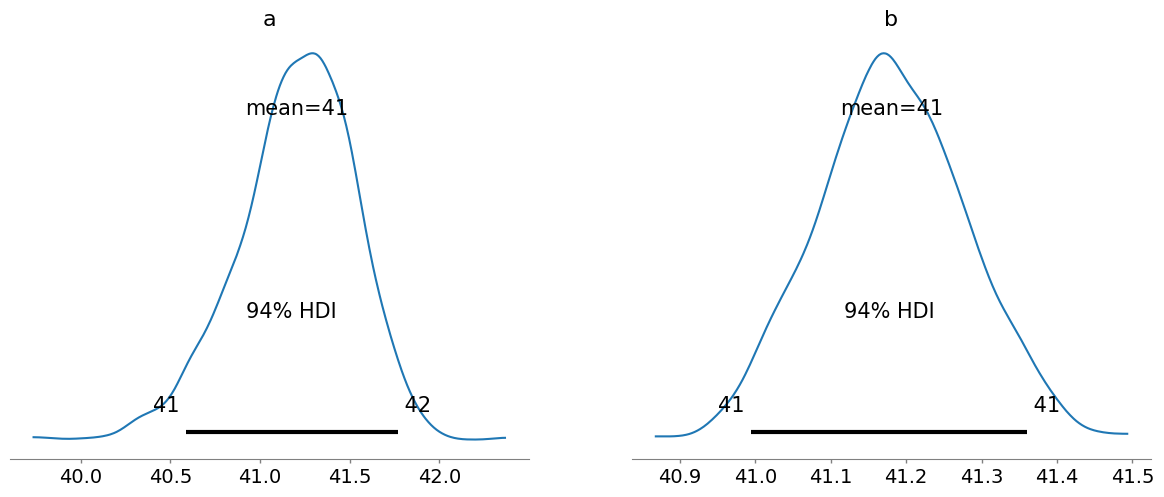

In [32]:
az.plot_posterior(idata_freestyleW)

array([[<Axes: >, None],
       [<Axes: xlabel='a', ylabel='b'>, <Axes: >]], dtype=object)

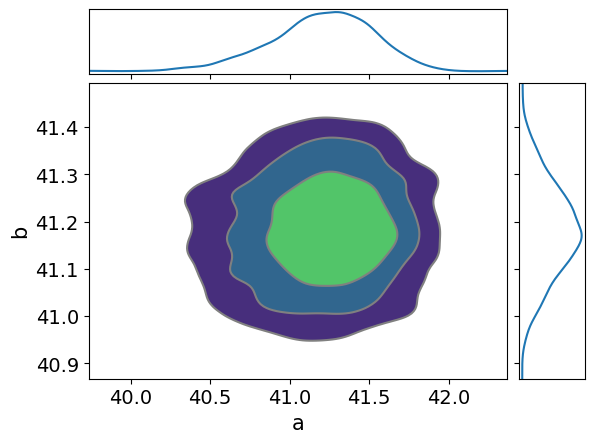

In [33]:
az.plot_pair(idata_freestyleW, kind='kde', marginals=True)

I thought this chart was pretty cool so I decided to include it. It's a useful visual when plotting the intersection of 2 related graphs.

In [ ]:
pm.sample_posterior_predictive(idata_freestyleW, model=model_freestyleW, extend_inferencedata=True)

<Axes: xlabel='Y'>

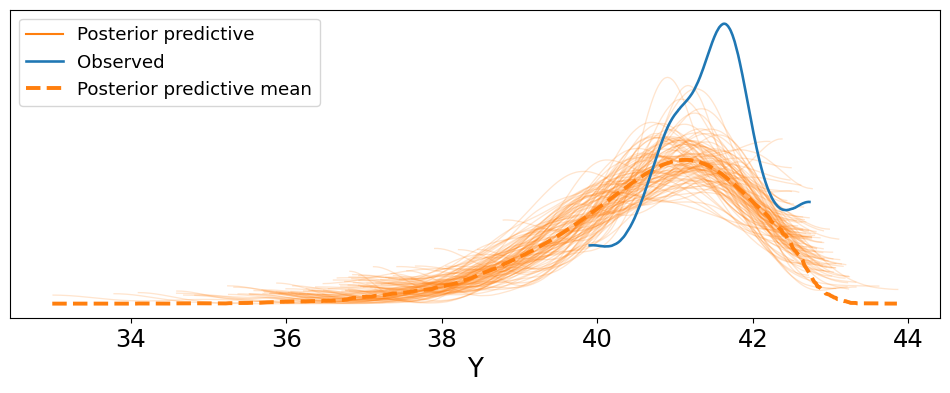

In [47]:
#The following code block is taken directly from the textbook BAP3.
#Plots the posterior predictive density overlaid with a smoothed version of the data

az.plot_ppc(idata_freestyleW, num_pp_samples=100, figsize=(12, 4), colors=["C1", "C0", "C1"])

We can see that the model is far off from the truth. This isn't very ideal. Taking a look at the posterior predictive mean, we can see that it's quite close to what we see in the data and what I think it actually is. Something quite odd is that it suggests that 100 freestyle times of 38 seconds are not impossible, while it effectively cuts off times slowe than 42 seconds. The peak of the graph seems to be around 41, which is always good to see. It exaggerates the fast times so much, almost to the point at which it is inhumane to at those speeds.

Let's try a different likelihood with the same prior (I like my priors) and see if we come up with something that's more accurate.

In [ ]:
#N for normal
with pm.Model() as model_freestyleN:
    #our prior for the mean
    μ = pm.SkewNormal("μ", mu=41.5, sigma=0.5, alpha=-2.0)

    #prior for variance
    σ = pm.HalfNormal('σ', sigma=1.06)

    #our fancy new likelihood, with two priors
    Y = pm.Normal('Y', mu = μ, sigma = σ, observed=race_times)
    idata_freestyleN = pm.sample()

In [ ]:
pm.sample_posterior_predictive(idata_freestyleN, model=model_freestyleN, extend_inferencedata=True)

<Axes: xlabel='Y'>

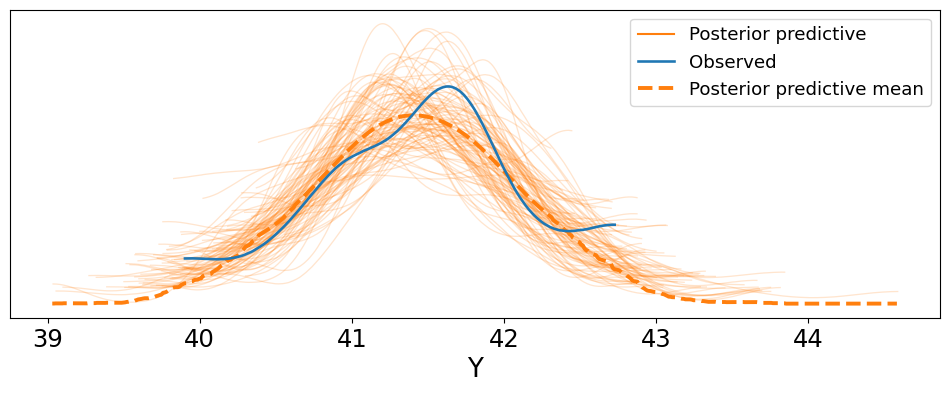

In [25]:
az.plot_ppc(idata_freestyleN, num_pp_samples=100, figsize=(12, 4), colors=["C1", "C0", "C1"])

It did a decent job matching the observed data with the posterior predictive mean. It seems like we've got something good going on here. However, there's still room for improvement, since there are many times where the observations overshoot/undershoot what's expected. I wouldn't say that we should put too much trust in this model because there are some guesses that are far off what we thought, but it's somewhat okay.

##**Closing Thoughts**

*   These times are freakishly fast...
*   Going low 39 seconds could be possible in the future
*  The Normal distribution was much more effective in my opinion. Let's take a look at why this may be the case. There is a much more strict definnition for what the normal distribution can take in as parameters. We need to have already known the mean of our data, making the prediction much more supported than any other one with only shape parameters. We're putting something that we can say is somewhat true to reality rather than guessing and checking alpha and beta values for distributions like Beta, Binomial, and Weibull etc.
*   The normal distribution is typically highly applicable in real world scenarios. I took this info from the wikipedia page: [Normal distribution](https://en.wikipedia.org/wiki/Normal_distribution). This is exciting and I hope to use it in the future
*   The true average of 100 yd freestyle times seem to actually be on the lower end of 41 seconds, around 41.3 seconds.





(If you were ever interested, only 3 men have ever gone sub 40 seconds in the 100 yd freestyle (along w/ the year they first did it at NCAAs): Caeleb Dressel (2018), Jordan Crooks (2025), Josh Liendo(2025. The fact Dressel did this 7 years before anyone else proves he's the short course yards GOAT)

